In [1]:
# Library import

import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import requests
from bs4 import BeautifulSoup

# Plot styling
sns.set_style('ticks')

#### 1. Dataset Loading

**---------- 1. DATASE LOADING ----------**

In [2]:
# Read tracks.csv
tracks = pd.read_csv('../data/kaggle2/tracks.csv')
tracks.head()

,id,name,popularity,duration_ms,explicit,artists,id_artists,release_date,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature
0,35iwgR4jXetI318WEWsa1Q,Carve,6,126903,0,['Uli'],['45tIt06XoI0Iio4LBEVpls'],1922-02-22,0.645,0.4450,0,-13.338,1,0.4510,0.674,0.7440,0.151,0.127,104.851,3
1,021ht4sdgPcrDgSk7JTbKY,Capítulo 2.16 - Banquero Anarquista,0,98200,0,['Fernando Pessoa'],['14jtPCOoNZwquk5wd9DxrY'],1922-06-01,0.695,0.2630,0,-22.136,1,0.9570,0.797,0.0000,0.148,0.655,102.009,1
2,07A5yehtSnoedViJAZkNnc,Vivo para Quererte - Remasterizado,0,181640,0,['Ignacio Corsini'],['5LiOoJbxVSAMkBS2fUm3X2'],1922-03-21,0.434,0.1770,1,-21.180,1,0.0512,0.994,0.0218,0.212,0.457,130.418,5
3,08FmqUhxtyLTn6pAh6bk45,El Prisionero - Remasterizado,0,176907,0,['Ignacio Corsini'],['5LiOoJbxVSAMkBS2fUm3X2'],1922-03-21,0.321,0.0946,7,-27.961,1,0.0504,0.995,0.9180,0.104,0.397,169.980,3
4,08y9GfoqCWfOGsKdwojr5e,Lady of the Evening,0,163080,0,['Dick Haymes'],['3BiJGZsyX9sJchTqcSA7Su'],1922,0.402,0.1580,3,-16.900,0,0.0390,0.989,0.1300,0.311,0.196,103.220,4


**---------- 2. DATA OVERVIEW ----------**

In [3]:
tracks.info()

<class 'pandas.DataFrame'>
RangeIndex: 586672 entries, 0 to 586671
Data columns (total 20 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   id                586672 non-null  str    
 1   name              586601 non-null  str    
 2   popularity        586672 non-null  int64  
 3   duration_ms       586672 non-null  int64  
 4   explicit          586672 non-null  int64  
 5   artists           586672 non-null  str    
 6   id_artists        586672 non-null  str    
 7   release_date      586672 non-null  str    
 8   danceability      586672 non-null  float64
 9   energy            586672 non-null  float64
 10  key               586672 non-null  int64  
 11  loudness          586672 non-null  float64
 12  mode              586672 non-null  int64  
 13  speechiness       586672 non-null  float64
 14  acousticness      586672 non-null  float64
 15  instrumentalness  586672 non-null  float64
 16  liveness          586672 non-nu

In [4]:
# Checking for null values 
tracks.isnull().sum()

id                   0
name                71
popularity           0
duration_ms          0
explicit             0
artists              0
id_artists           0
release_date         0
danceability         0
energy               0
key                  0
loudness             0
mode                 0
speechiness          0
acousticness         0
instrumentalness     0
liveness             0
valence              0
tempo                0
time_signature       0
dtype: int64

**---------- 3. DATA CLEANING ----------**

In [5]:
# --- 1. Handle missing names ---
tracks['name'] = tracks['name'].fillna("Unknown Track")

In [6]:
# --- 2. Dealing with "stringified" lists ---
"""                     ↓
The `artists` and `id_artists` columns were imported as stringified lists. 
Because Python interprets these as literal strings rather than list objects, 
individual elements are not directly accessible for analysis.
"""

# Check 'artists' and 'id_artists' columns before trasformation:
print(f"""      --- 'artists' column ---
{tracks['artists'].tail()}

      --- 'id_artists' column ---
{tracks['id_artists'].tail()}""")

      --- 'artists' column ---
586667                        ['阿YueYue']
586668                     ['ROLE MODEL']
586669                        ['FINNEAS']
586670    ['Gentle Bones', 'Clara Benin']
586671                      ['Afrosound']
Name: artists, dtype: str

      --- 'id_artists' column ---
586667                           ['1QLBXKM5GCpyQQSVMNZqrZ']
586668                           ['1dy5WNgIKQU6ezkpZs4y8z']
586669                           ['37M5pPGs6V1fchFJSgCguX']
586670    ['4jGPdu95icCKVF31CcFKbS', '5ebPSE9YI5aLeZ1Z2g...
586671                           ['0i4Qda0k4nf7jnNHmSNpYv']
Name: id_artists, dtype: str


In [7]:
## --- STEP 1: Clean the string by removing list symbols ---
tracks['artists'] = tracks['artists'].str.replace("[", "", regex=False).str.replace("]", "", regex=False).str.replace("'", "", regex=False)
tracks['id_artists'] = tracks['id_artists'].str.replace("[", "", regex=False).str.replace("]", "", regex=False).str.replace("'", "", regex=False)

## --- STEP 2: Split the string to create a list ---
tracks['artists'] = tracks['artists'].str.split(", ")
tracks['id_artists'] = tracks['id_artists'].str.split(", ")

## --- STEP 3: Extract the first element (Main Artist) ---
tracks['main_artist'] = tracks['artists'].str[0]
tracks['id_main_artist'] = tracks['id_artists'].str[0]

In [8]:
# Check 'artists' and 'id_artists' columns after trasformation:
print(f"""      --- 'artists' column ---
{tracks['artists'].tail()}

      --- 'id_artists' column ---
{tracks['id_artists'].tail()}""")

      --- 'artists' column ---
586667                      [阿YueYue]
586668                   [ROLE MODEL]
586669                      [FINNEAS]
586670    [Gentle Bones, Clara Benin]
586671                    [Afrosound]
Name: artists, dtype: object

      --- 'id_artists' column ---
586667                            [1QLBXKM5GCpyQQSVMNZqrZ]
586668                            [1dy5WNgIKQU6ezkpZs4y8z]
586669                            [37M5pPGs6V1fchFJSgCguX]
586670    [4jGPdu95icCKVF31CcFKbS, 5ebPSE9YI5aLeZ1Z2gkqjn]
586671                            [0i4Qda0k4nf7jnNHmSNpYv]
Name: id_artists, dtype: object


In [9]:
# --- 3. Handling Inconsistent Formats ---
"""                    ↓
- This Spotify dataset presents inconsistent date formats. 
  In some case full dates (YYYY-MM-DD) are present, in others year-only entries (YYYY). 
  Not knowing which other formats are present, we used this code to filter out any value 
  shorter than the standard 10 characters.
- By extracting the unique values from this subset, we were able to identify exactly which 
patterns were present (such as YYYY or YYYY-MM).
"""

# Check 'release_date' column before trasformation:
tracks.release_date

0         1922-02-22
1         1922-06-01
2         1922-03-21
3         1922-03-21
4               1922
             ...    
586667    2020-09-26
586668    2020-10-21
586669    2020-09-02
586670    2021-03-05
586671    2015-07-01
Name: release_date, Length: 586672, dtype: str

In [10]:
# Create a mask for strings with lengths shorter than a full date (10 characters) ---
# This helps identify years (length 4) and month-year formats (length 7)
anomaly_mask = (tracks['release_date'].str.len() < 10)

# Display unique values to understand the specific formats present ---
anomalous_values = tracks.loc[anomaly_mask, 'release_date'].unique()
print(anomalous_values)

<StringArray>
[   '1922',    '1923',    '1924',    '1925',    '1926',    '1927',    '1928',
    '1929',    '1930',    '1931',
 ...
 '1973-01', '1976-03', '1981-05', '1983-09', '1985-04', '1996-03', '1980-10',
 '1981-10', '1999-10', '1991-05']
Length: 340, dtype: str


In [11]:
# --- STEP 1: Handle year-only dates (YYYY) ---
# Check for strings with 4 characters and set them to 01-01
mask_year = tracks['release_date'].str.len() == 4
tracks.loc[mask_year, 'release_date'] = tracks.loc[mask_year, 'release_date'] + '-01-01'

# --- STEP 2: Handle year-month dates (YYYY-MM) ---
# Check for strings with 7 characters and set them to the 01 day of that month
mask_month = tracks['release_date'].str.len() == 7
tracks.loc[mask_month, 'release_date'] = tracks.loc[mask_month, 'release_date'] + '-01'

# --- STEP 3: Final Conversion ---
# Now that formats are standardized to YYYY-MM-DD, convert to datetime objects
tracks['release_date'] = pd.to_datetime(tracks['release_date'], errors='coerce')

# Check if any NaT (errors) remain
print(f"Remaining invalid dates: {tracks['release_date'].isna().sum()}")

Remaining invalid dates: 0


In [12]:
# --- 4. Convert song duration from [ms] to [min] ---

# --- STEP 1: Transform duration_ms in duration_min ---
tracks['duration_ms'] = tracks['duration_ms'] / (1000 * 60)
# --- STEP 2: Rename duration_ms in duration_min ---
tracks = tracks.rename(columns={'duration_ms': 'duration_min'})
tracks.duration_min.head()

0    2.115050
1    1.636667
2    3.027333
3    2.948450
4    2.718000
Name: duration_min, dtype: float64

In [13]:
# Drop any duplicate record to avoid distortions
tracks = tracks.drop_duplicates(subset=['id'])

#### 2. Audio features analysis

**--- SPOTIFY AUDIO FEATURES - REFERENCE GUIDE ---**

> Full documentation of the audio features returned by the  [Spotify Web API](https://developer.spotify.com/documentation/web-api/reference/get-audio-features)

**0️⃣1️⃣ Numeric Features (0.0 – 1.0 scale)**

| Feature | Description | Range |
|---|---|---|
| `acousticness` | Confidence the track is acoustic. 1.0 = highly acoustic | 0.0 – 1.0 |
| `danceability` | Suitability for dancing (tempo, rhythm, beat strength) | 0.0 – 1.0 |
| `energy` | Perceptual intensity and activity. High = fast, loud, noisy | 0.0 – 1.0 |
| `instrumentalness` | Likelihood of no vocal content. >0.5 = likely instrumental | 0.0 – 1.0 |
| `liveness` | Presence of audience. >0.8 = likely live recording | 0.0 – 1.0 |
| `speechiness` | Presence of spoken words. >0.66 = speech, <0.33 = music | 0.0 – 1.0 |
| `valence` | Musical positiveness. High = happy/euphoric, Low = sad/angry | 0.0 – 1.0 |

**🔢 Other Numeric Features**

| Feature | Description | Range |
|---|---|---|
| `loudness` | Overall loudness in decibels (dB), averaged across track | -60 – 0 dB |
| `tempo` | Estimated BPM (beats per minute) | — |
| `duration_ms` | Track duration in milliseconds | — |

**🅰️🅱️ Categorical / Integer Features**

| Feature | Description | Range |
|---|---|---|
| `key` | Musical key using [Pitch Class](https://en.wikipedia.org/wiki/Pitch_class) notation (0=C, 1=C♯/D♭, ... 11=B). -1 if undetected | -1 – 11 |
| `mode` | Scale modality: **1 = Major**, **0 = Minor** | 0 or 1 |
| `time_signature` | Estimated beats per bar (e.g. 4 = "4/4" time) | 3 – 7 |

In [14]:
# --- 1. Inspection and conversion of the 'key' column ---

print(f"""
Key unique values:
{sorted(tracks['key'].unique().tolist())}
""")


Key unique values:
[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11]



**DATA ENRICHMENT: add the 'key_name' column**

In [17]:
# --- STEP 1: Get the url ---
url = 'https://en.wikipedia.org/wiki/Pitch_class'

# --- STEP 2: Define headers for the request ---
headers = {
    'User-Agent': 'SpotifyAnalysisProject/1.0 (manuel.cernigoj@gmail.com)'
    }

# --- STEP 3: Get page information with requests ---
page = requests.get(url, headers=headers)

print(f"""
Page status code: 
{page.status_code}
Page preview: 
{page.text[:500]}
""")


Page status code: 
200
Page preview: 
<!DOCTYPE html>
<html class="client-nojs vector-feature-language-in-header-enabled vector-feature-language-in-main-menu-disabled vector-feature-language-in-main-page-header-disabled vector-feature-page-tools-pinned-disabled vector-feature-toc-pinned-clientpref-1 vector-feature-main-menu-pinned-disabled vector-feature-limited-width-clientpref-1 vector-feature-limited-width-content-enabled vector-feature-custom-font-size-clientpref-1 vector-feature-appearance-pinned-clientpref-1 skin-theme-clientp



In [18]:
# --- STEP 4: Parsing html page with 'BeautifulSoup' ---
soup = BeautifulSoup(page.content, "html.parser")

# Look for the specific table
table = soup.find(class_="wikitable")

# Extract each row in a list
rows = table.find_all('tr')

In [19]:
# --- STEP 5: Extract 'pitch' & 'key_name' ---

pitch_classes = []

# Cycle in each row and extract 'pitch' & 'key_name'
for row in rows[1:]:

    # 'pitch' informations
    th = row.find('th')
    pitch = th.text.strip().split(',')[0].strip()

    # 'key_name' informations
    td = row.find('td')
    tonal = td.text.strip().split(',')[0].strip()
        
    # List .append
    pitch_classes.append({
        'pitch': pitch,
        'key_name': tonal
    })

pitch_classes

[{'pitch': '0', 'key_name': 'C'},
 {'pitch': '1', 'key_name': 'C♯'},
 {'pitch': '2', 'key_name': 'D'},
 {'pitch': '3', 'key_name': 'D♯'},
 {'pitch': '4', 'key_name': 'E'},
 {'pitch': '5', 'key_name': 'F'},
 {'pitch': '6', 'key_name': 'F♯'},
 {'pitch': '7', 'key_name': 'G'},
 {'pitch': '8', 'key_name': 'G♯'},
 {'pitch': '9', 'key_name': 'A'},
 {'pitch': '10', 'key_name': 'A♯'},
 {'pitch': '11', 'key_name': 'B'}]

In [20]:
# List to Df conversion
df_keys = pd.DataFrame(pitch_classes)
df_keys

,pitch,key_name
0,0,C
1,1,C♯
2,2,D
3,3,D♯
4,4,E
5,5,F
6,6,F♯
7,7,G
8,8,G♯
9,9,A


In [21]:
# Check datatypes
df_keys.info()

<class 'pandas.DataFrame'>
RangeIndex: 12 entries, 0 to 11
Data columns (total 2 columns):
 #   Column    Non-Null Count  Dtype
---  ------    --------------  -----
 0   pitch     12 non-null     str  
 1   key_name  12 non-null     str  
dtypes: str(2)
memory usage: 324.0 bytes


In [22]:
# 'pitch' conversion from [str] to [int]
df_keys['pitch'] = df_keys['pitch'].astype(int)
df_keys.info()

<class 'pandas.DataFrame'>
RangeIndex: 12 entries, 0 to 11
Data columns (total 2 columns):
 #   Column    Non-Null Count  Dtype
---  ------    --------------  -----
 0   pitch     12 non-null     int64
 1   key_name  12 non-null     str  
dtypes: int64(1), str(1)
memory usage: 324.0 bytes


In [23]:
# --- STEP 6. Integrate 'key_name' information into tracks trough a join ---
tracks = tracks.merge(df_keys, how = 'left', left_on = 'key', right_on = 'pitch')
tracks.head()

,id,name,popularity,duration_min,explicit,artists,id_artists,release_date,danceability,energy,...,acousticness,instrumentalness,liveness,valence,tempo,time_signature,main_artist,id_main_artist,pitch,key_name
0,35iwgR4jXetI318WEWsa1Q,Carve,6,2.115050,0,[Uli],[45tIt06XoI0Iio4LBEVpls],1922-02-22,0.645,0.4450,...,0.674,0.7440,0.151,0.127,104.851,3,Uli,45tIt06XoI0Iio4LBEVpls,0,C
1,021ht4sdgPcrDgSk7JTbKY,Capítulo 2.16 - Banquero Anarquista,0,1.636667,0,[Fernando Pessoa],[14jtPCOoNZwquk5wd9DxrY],1922-06-01,0.695,0.2630,...,0.797,0.0000,0.148,0.655,102.009,1,Fernando Pessoa,14jtPCOoNZwquk5wd9DxrY,0,C
2,07A5yehtSnoedViJAZkNnc,Vivo para Quererte - Remasterizado,0,3.027333,0,[Ignacio Corsini],[5LiOoJbxVSAMkBS2fUm3X2],1922-03-21,0.434,0.1770,...,0.994,0.0218,0.212,0.457,130.418,5,Ignacio Corsini,5LiOoJbxVSAMkBS2fUm3X2,1,C♯
3,08FmqUhxtyLTn6pAh6bk45,El Prisionero - Remasterizado,0,2.948450,0,[Ignacio Corsini],[5LiOoJbxVSAMkBS2fUm3X2],1922-03-21,0.321,0.0946,...,0.995,0.9180,0.104,0.397,169.980,3,Ignacio Corsini,5LiOoJbxVSAMkBS2fUm3X2,7,G
4,08y9GfoqCWfOGsKdwojr5e,Lady of the Evening,0,2.718000,0,[Dick Haymes],[3BiJGZsyX9sJchTqcSA7Su],1922-01-01,0.402,0.1580,...,0.989,0.1300,0.311,0.196,103.220,4,Dick Haymes,3BiJGZsyX9sJchTqcSA7Su,3,D♯


In [24]:
# --- 2. Inspection and conversion of the 'mode' column ---

print(f"""
Mode unique values:
{sorted(tracks['mode'].unique().tolist())}
""")


Mode unique values:
[0, 1]



**DATA ENRICHMENT: add the 'mode_name' column**

In [25]:
tracks['mode_name'] = tracks['mode'].map({
    0: 'Minor', 
    1: 'Major'
    })

In [ ]:
# --- Creating separate lists based on the 'type' of audio feature ---

features_list_num = [
    'loudness', 'tempo', 'duration_min'
    ]

features_list_cat = [
    'key_name', 'mode_name', 'time_signature'
    ]

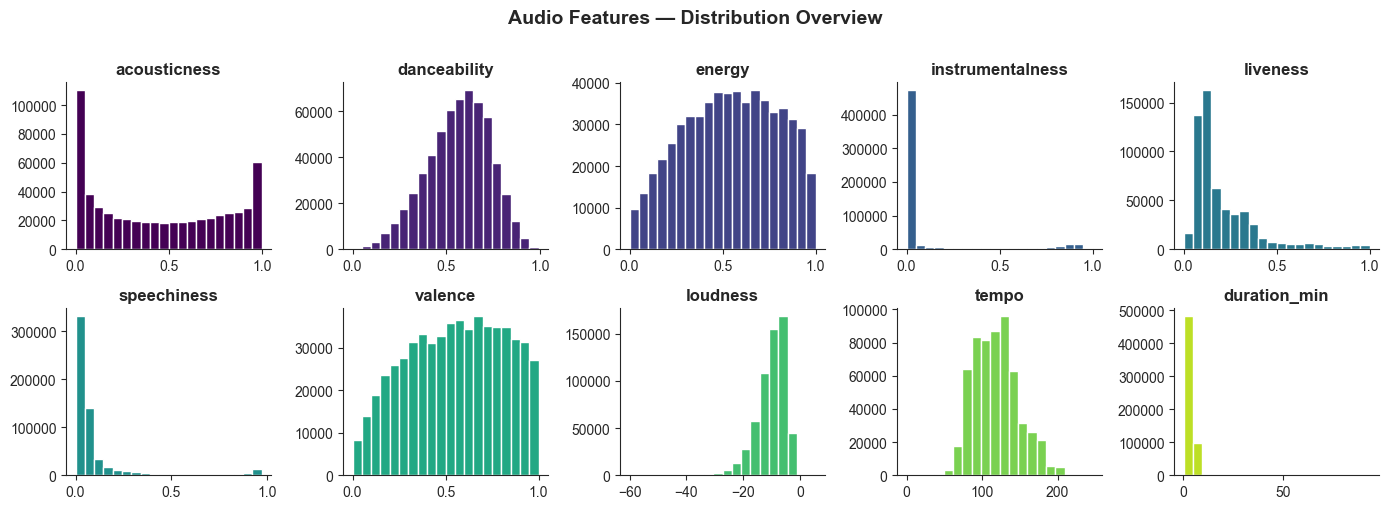

In [26]:
features_list_all = [
    'acousticness', 'danceability', 
    'energy', 'instrumentalness',
    'liveness', 'speechiness', 'valence',
    'loudness', 'tempo', 'duration_min'
    ]

# --- Distribution of 0_1 audio features ---
fig, axes = plt.subplots(2, 5, figsize=(14, 5))
axes = axes.flatten()

# Generate 7 evenly spaced colors from the viridis palette
colors = [plt.cm.viridis(i / len(features_list_all)) for i in range(len(features_list_all))]

for i, (feature, color) in enumerate(zip(features_list_all, colors)):
    axes[i].hist(tracks[feature].dropna(), bins=20,
                 color=color, edgecolor='white')
    axes[i].set_title(feature, fontweight='bold')
    axes[i].set_xlabel('')
    axes[i].set_ylabel('')
    sns.despine(ax=axes[i])

# Hide unused axes
for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Audio Features — Distribution Overview',
             fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

In [27]:
# --- FEATURE CLASSIFICATION ---

# IQR cleaning (symmetric distributions)
iqr_features       = ['tempo']

# Log + IQR cleaning (right-skewed, positive distributions)
log_iqr_features   = ['loudness', 'duration_min']
# Since loudness values are negative, before log transform, a value shift is required
LOUDNESS_SHIFT = abs(tracks['loudness'].min())

# Untouched: bounded 0-1 by Spotify's design, no cleaning needed
untouched_features = ['acousticness', 'danceability', 'energy', 'liveness,'
                      'valence', 'speechiness', 'instrumentalness']

In [28]:
# --- FUNCTIONS DEFINITION ---

def apply_iqr(df, features, fence=1.5):
    """
    Removes rows where values fall outside the IQR-based bounds.
    Best for roughly symmetric distributions.
    
    Parameters:
        df       : input DataFrame
        features : list of column names to clean
        fence    : IQR multiplier (1.5 = standard, 3.0 = conservative)
    """
    mask = pd.Series([True] * len(df), index=df.index)

    for col in features:
        Q1  = df[col].quantile(0.25)
        Q3  = df[col].quantile(0.75)
        IQR = Q3 - Q1

        lb = Q1 - fence * IQR   # Lower Bound
        ub = Q3 + fence * IQR   # Upper Bound

        col_mask = (df[col] >= lb) & (df[col] <= ub)
        mask     = mask & col_mask

        print(f"  [IQR] {col}: bounds ({lb:.2f}, {ub:.2f}) "
              f"— removed {(~col_mask).sum()} rows")

    return df[mask]

# -----------------------------------------------------------

def apply_log_iqr(df, features, fence=1.5):
    """
    Applies log1p transformation before computing IQR bounds, then
    converts the threshold back to the original scale before filtering.
    Best for right-skewed, positive distributions.

    Parameters:
        df       : input DataFrame
        features : list of column names to clean
        fence    : IQR multiplier (1.5 = standard, 3.0 = conservative)
    """
    mask = pd.Series([True] * len(df), index=df.index)

    for col in features:
        log_col = np.log1p(df[col])   # transform to log scale

        Q1  = log_col.quantile(0.25)
        Q3  = log_col.quantile(0.75)
        IQR = Q3 - Q1

        # Compute bounds on log scale, then convert back to original scale
        lb = np.expm1(Q1 - fence * IQR)
        ub = np.expm1(Q3 + fence * IQR)

        col_mask = (df[col] >= lb) & (df[col] <= ub)
        mask     = mask & col_mask

        print(f"  [Log+IQR] {col}: bounds ({lb:.2f}, {ub:.2f}) "
              f"— removed {(~col_mask).sum()} rows")

    return df[mask]

# -----------------------------------------------------------

def apply_noise_filter(df, keywords, columns=['name']):
    """
    Removes rows where any of the given columns contain noise keywords.
    Useful for filtering out non-music tracks (e.g. sleep sounds, live
    recordings, medleys) that would distort audio feature analysis.

    Parameters:
        df       : input DataFrame
        keywords : list of strings to filter out (case-insensitive)
        columns  : list of column names to search in (default: ['name'])
    """
    # Build a single regex pattern by joining all keywords with OR operator
    # e.g. ['white noise', 'rain'] → 'white noise|rain'
    pattern = '|'.join(keywords)

    # Start with all rows marked as valid
    mask = pd.Series([True] * len(df), index=df.index)

    for col in columns:
        # Case-insensitive match — na=False treats missing values as no match
        col_mask = ~df[col].str.lower().str.contains(pattern, na=False)
        mask     = mask & col_mask

        print(f"  [Noise Filter] '{col}': removed {(~col_mask).sum()} rows")

    return df[mask]

In [29]:
# --- NOISE KEYWORDS ---
noise_keywords = [
    'white noise', 'brown noise', 'baby sleep', 'ocean waves',
    'rain sounds', 'meditation', 'shhh', 'ao vivo',
    'previa', 'medley', 'mixtape', 'concert'
]

In [30]:
# --- CLEANING FUNCTIONS CALLING ---

print("=" * 55)
print("  CLEANING PIPELINE")
print("=" * 55)

tracks_clean = tracks.copy()

# shift loudness to positive
tracks_clean['loudness'] = tracks_clean['loudness'] + LOUDNESS_SHIFT

print(f"\n→ Initial rows: {len(tracks_clean)}")

# --- 1. IQR on tempo ---
print("\n[1/3] IQR cleaning:")
tracks_clean = apply_iqr(tracks_clean, iqr_features, fence=1.5)

# --- 2. Log+IQR on loudness and duration_min ---
print("\n[2/3] Log + IQR cleaning:")
tracks_clean = apply_log_iqr(tracks_clean, log_iqr_features, fence=3)

# restore original loudness scale
tracks_clean['loudness'] = tracks_clean['loudness'] - LOUDNESS_SHIFT

# --- 3. Noise keyword filter ---
print("\n[3/3] Noise keyword filter:")
tracks_clean = apply_noise_filter(tracks_clean, noise_keywords, columns=['name'])

# --- untouched_features: no action needed ---

print("\n" + "=" * 55)
print(f"  DONE — Rows kept: {len(tracks_clean)} / {len(tracks)} "
      f"({len(tracks_clean) / len(tracks) * 100:.1f}%)")
print("=" * 55)

  CLEANING PIPELINE

→ Initial rows: 586672

[1/3] IQR cleaning:
  [IQR] tempo: bounds (34.52, 197.40) — removed 5709 rows

[2/3] Log + IQR cleaning:
  [Log+IQR] loudness: bounds (32.05, 78.34) — removed 3758 rows
  [Log+IQR] duration_min: bounds (0.50, 13.12) — removed 3057 rows

[3/3] Noise keyword filter:
  [Noise Filter] 'name': removed 4607 rows

  DONE — Rows kept: 569618 / 586672 (97.1%)


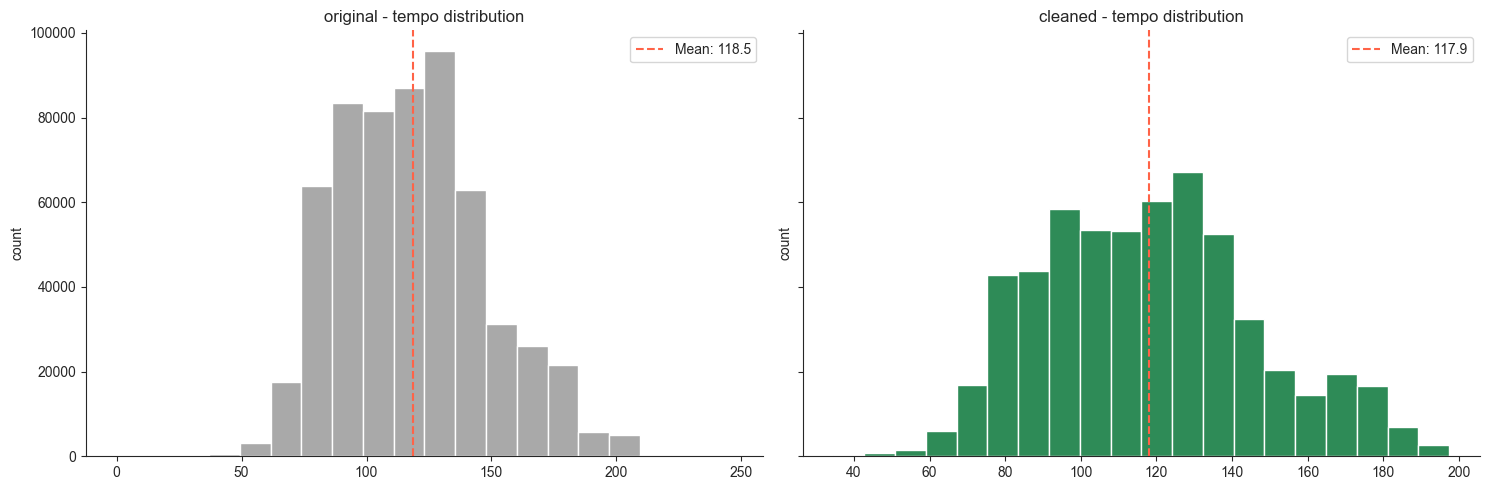

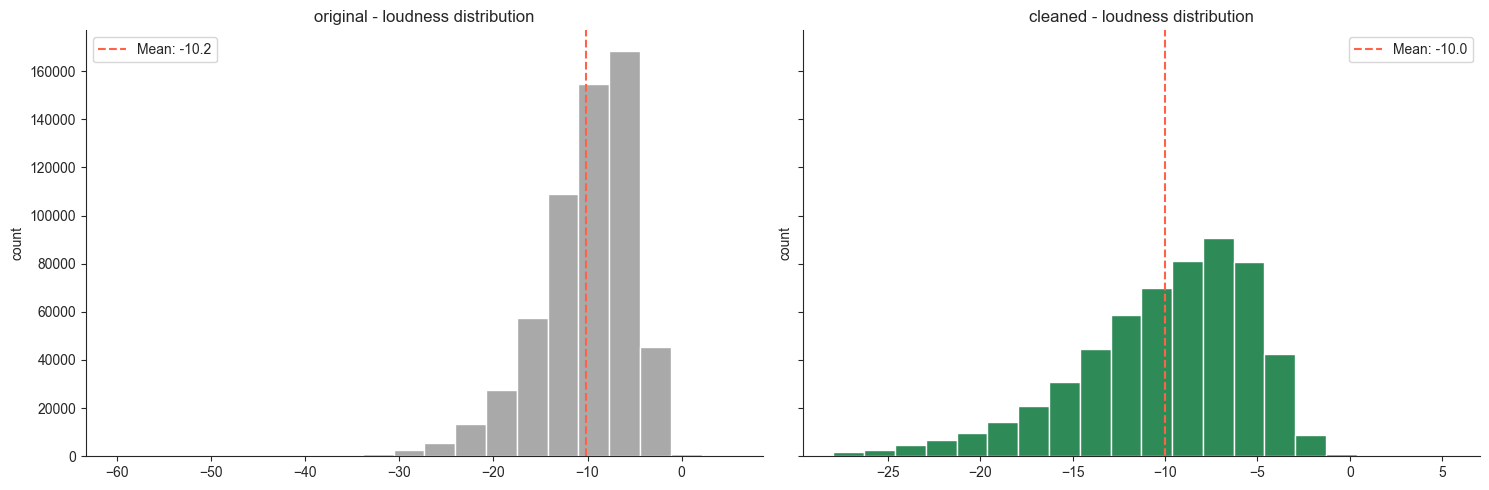

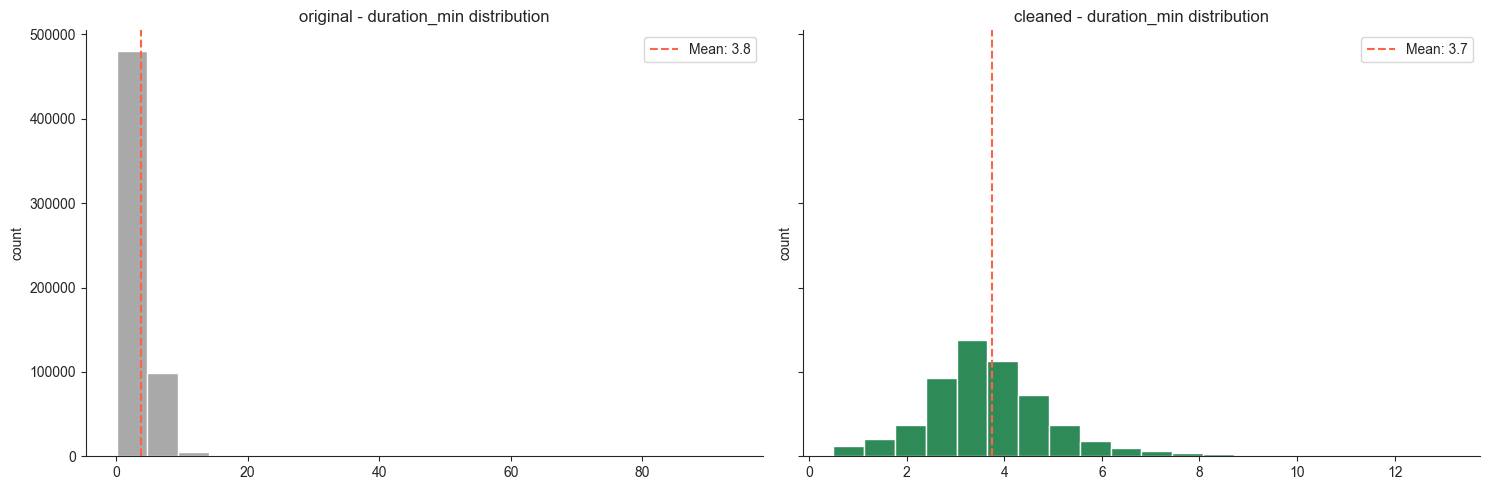

In [31]:
dfs = [tracks, tracks_clean]
labels = ['original', 'cleaned']
colors = ['darkgrey', 'seagreen']
columns = iqr_features + log_iqr_features

for column in columns:
    column = column
    fig, axes = plt.subplots(1, 2, figsize = (15, 5), sharey=True)

    for ax, df, label, color in zip(axes, dfs, labels, colors):
        ax.hist(df[column], bins = 20, color = color, edgecolor = 'white')
        ax.set_title(f"{label} - {column} distribution", fontsize = 12)
        ax.set_xlabel('')
        ax.set_ylabel('count')
        ax.axvline(df[column].mean(), color = 'tomato', linestyle='--', linewidth=1.5, label=f'Mean: {df[column].mean():.1f}')
        ax.legend()
        sns.despine(ax=ax)
    
    plt.tight_layout()
    plt.show()

**TEMPORAL ANALYSIS**

In [32]:
# Extract year
tracks_clean['year'] = tracks_clean['release_date'].dt.year

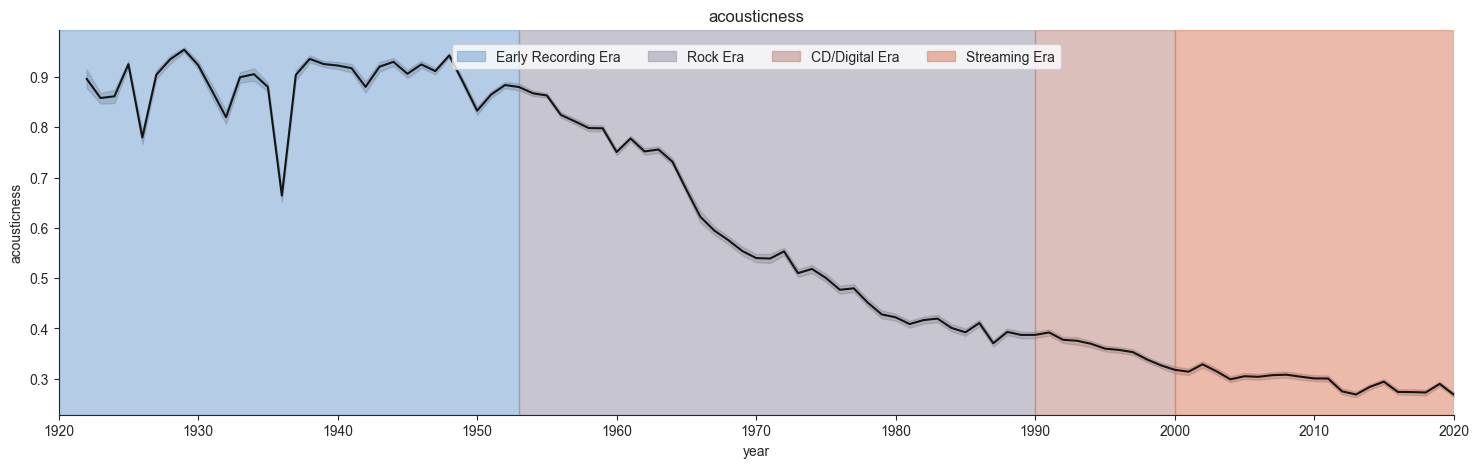

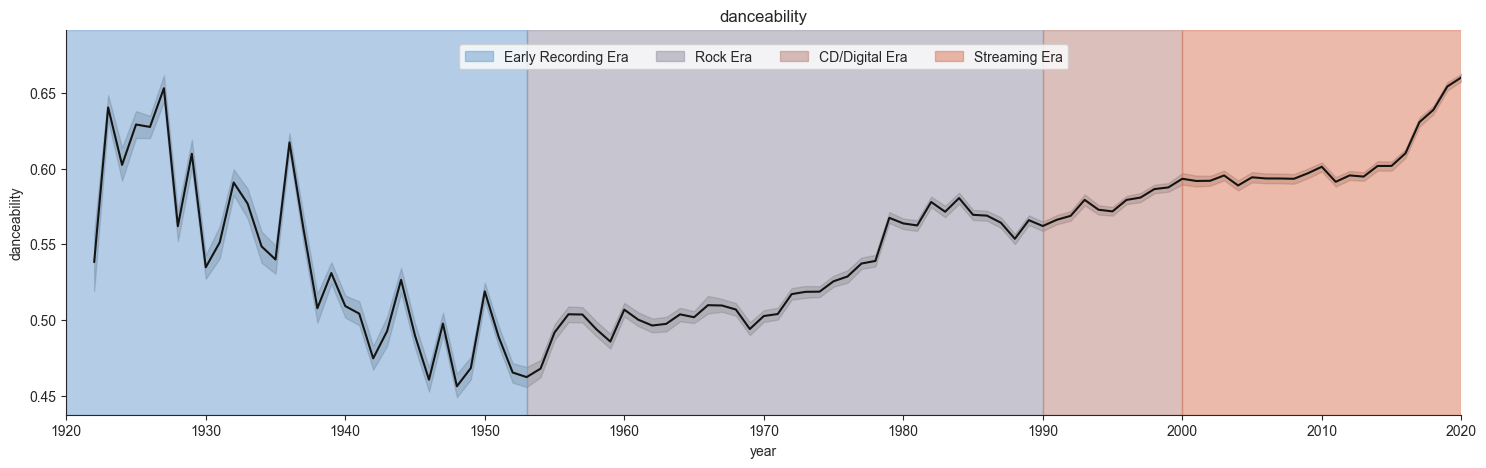

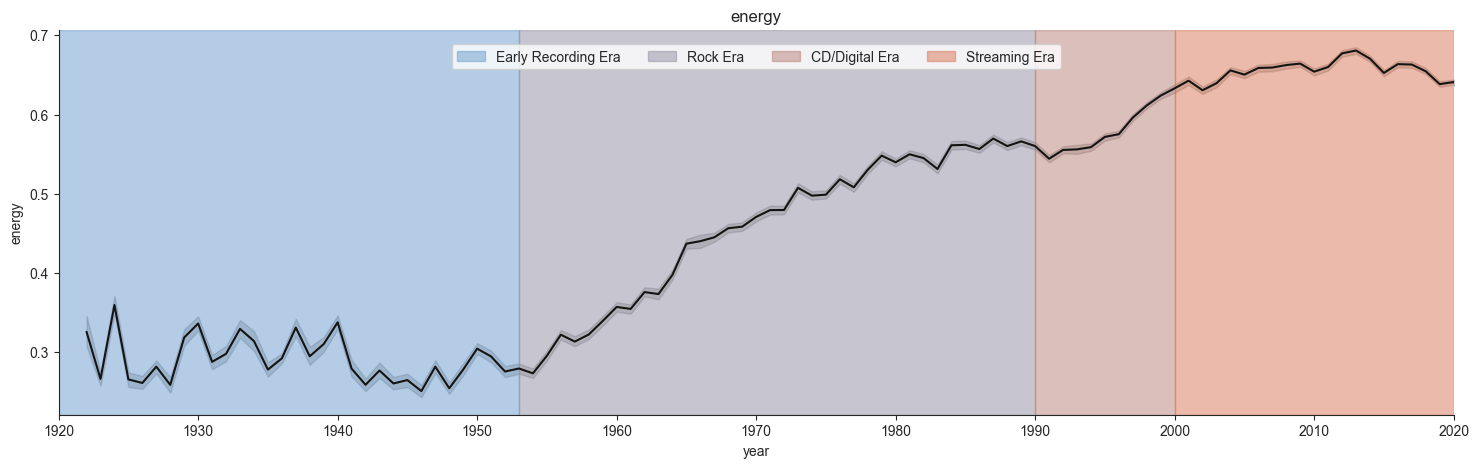

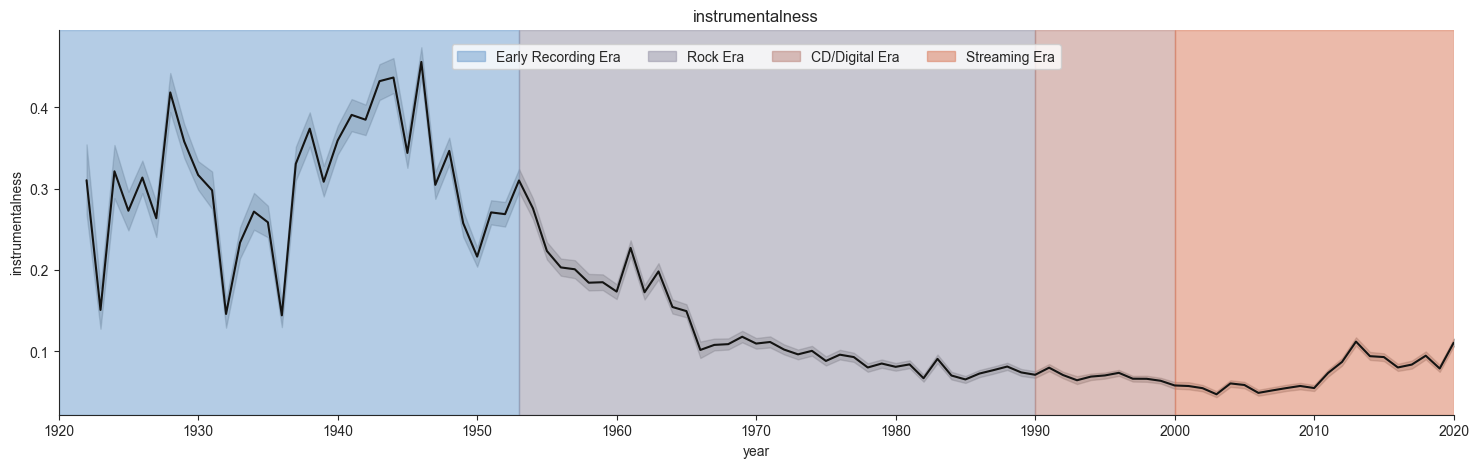

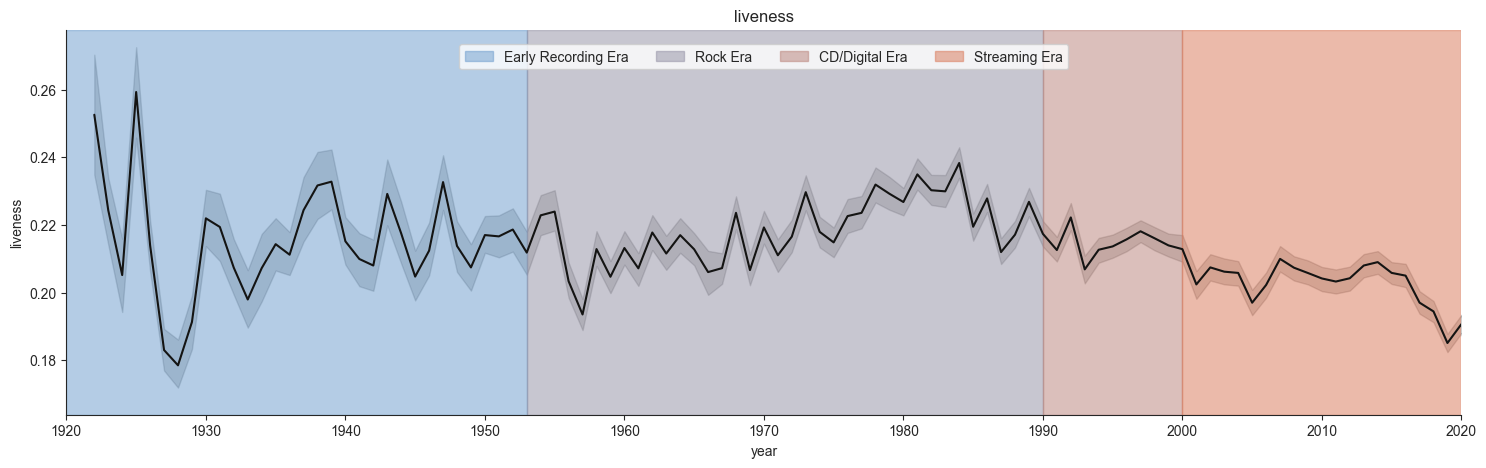

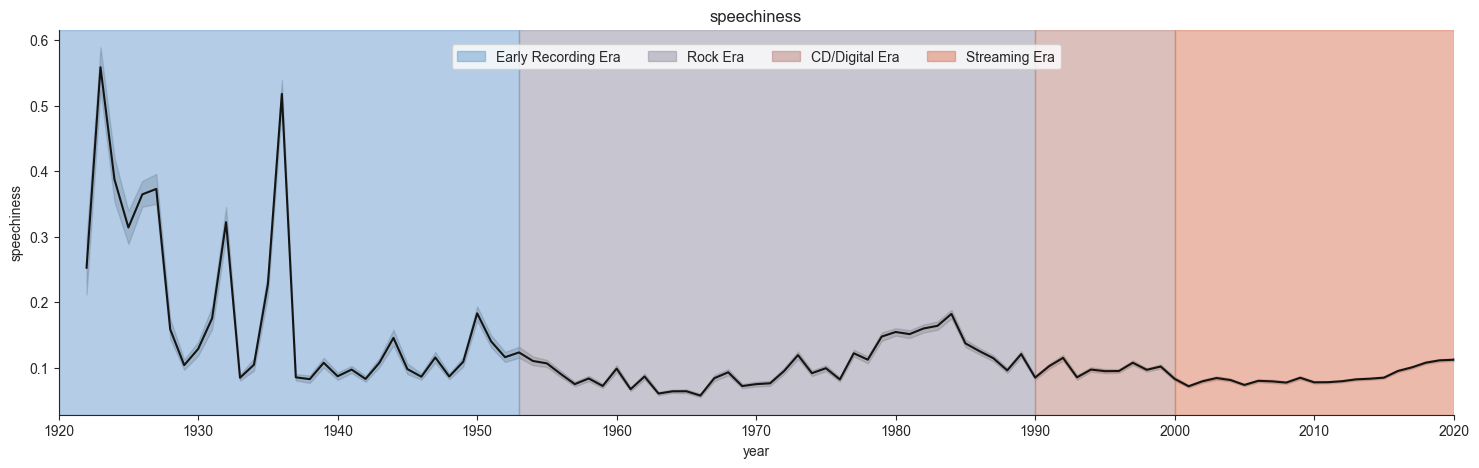

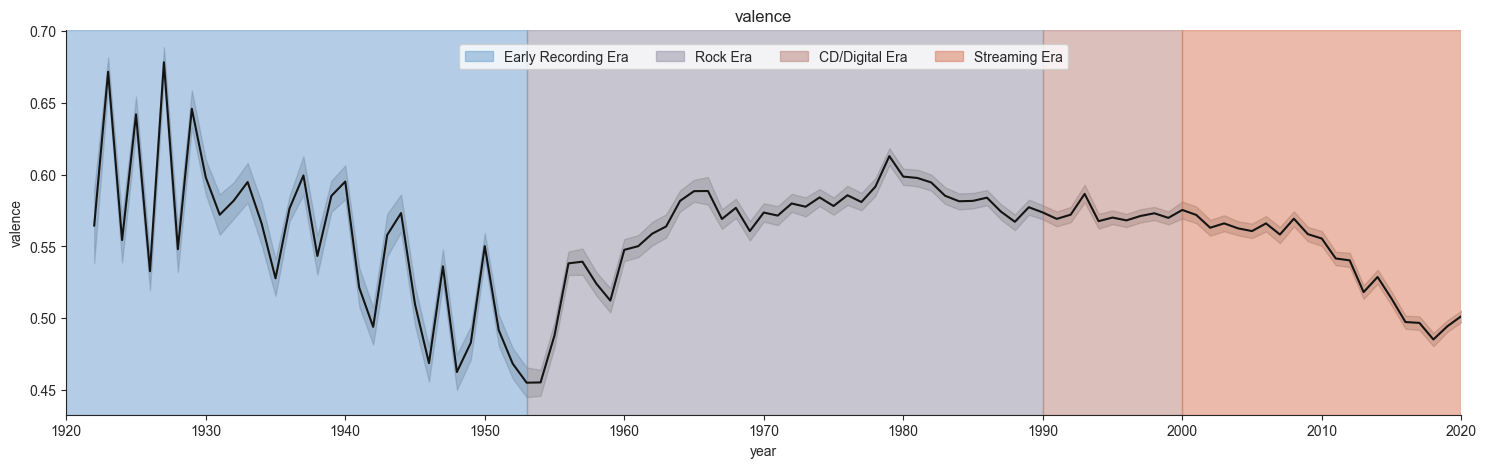

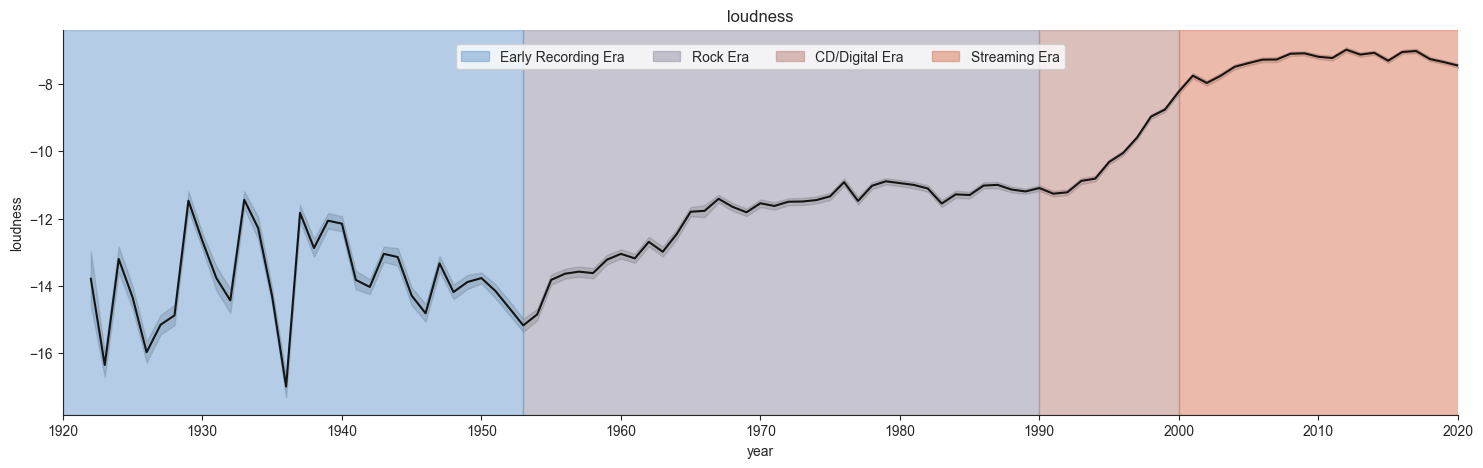

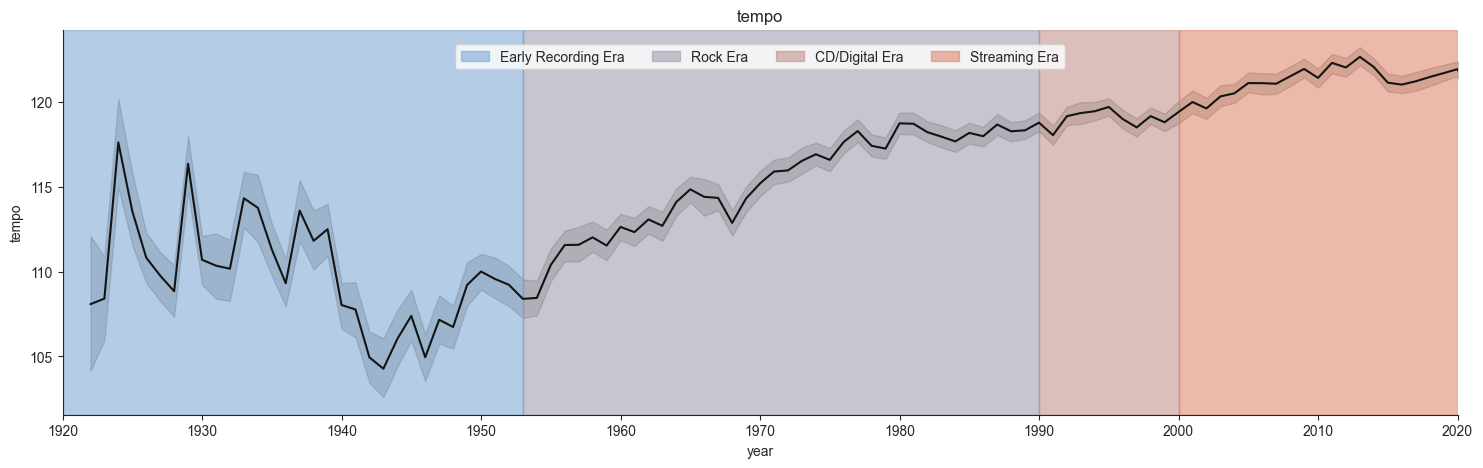

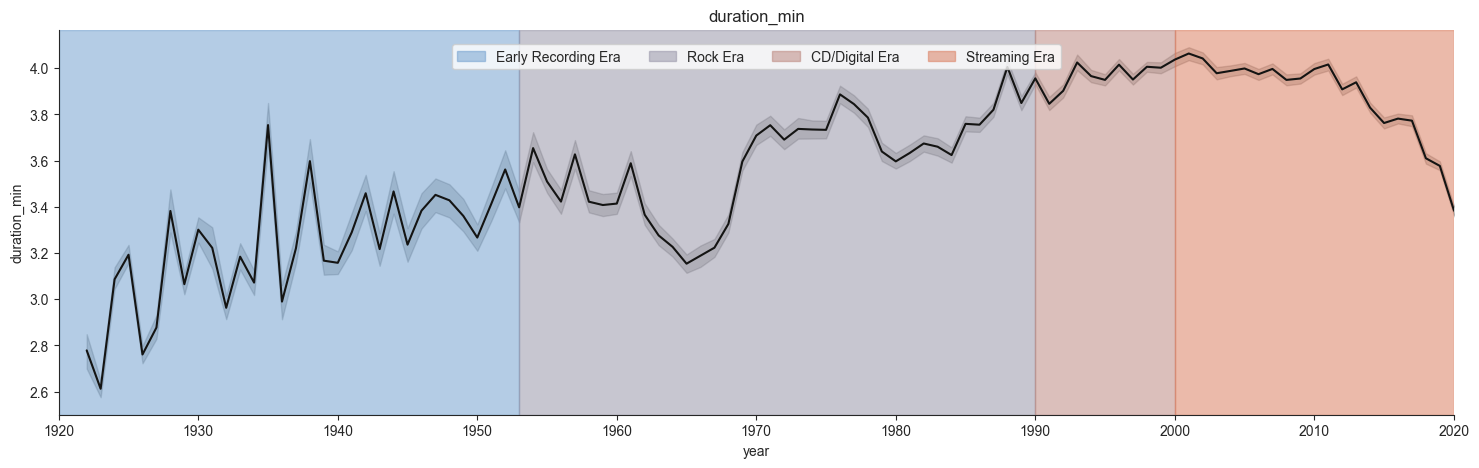

In [43]:
# Eras definition
eras = [
    (1920, 1953, '#6a9bcc', 'Early Recording Era'),
    (1953, 1990, '#918fa3', 'Rock Era'),
    (1990, 2000, '#b98178', 'CD/Digital Era'),
    (2000, 2020, '#d97757', 'Streaming Era'),
]

for f in features_list_all:
    fig, ax = plt.subplots(figsize=(18, 5))
    
    # Plot the feature (single color)
    sns.lineplot(tracks_clean[tracks_clean['year'] >= 1920], 
                 x='year', y=f, color='#141413', ax=ax)

    # Shaded era regions
    for start, end, color, label in eras:
        ax.axvspan(start, end, alpha=0.5, color=color, label=label)

    ax.set_title(f)
    ax.set_xlim(1920, 2020)
    ax.set_xticks(range(1920, 2021, 10))
    ax.legend(
    loc='upper center',        # ancora la legend in alto al centro
    bbox_to_anchor=(0.5, 0.98), # (50% x, leggermente sopra il plot)
    ncols=4,                   # 4 categorie = 4 colonne orizzontali
    fontsize=10
    )
    sns.despine()

plt.show()

In [31]:
print(tracks.info())
tracks.head()

<class 'pandas.DataFrame'>
RangeIndex: 586672 entries, 0 to 586671
Data columns (total 26 columns):
 #   Column            Non-Null Count   Dtype         
---  ------            --------------   -----         
 0   id                586672 non-null  str           
 1   name              586672 non-null  str           
 2   popularity        586672 non-null  int64         
 3   duration_min      586672 non-null  float64       
 4   explicit          586672 non-null  int64         
 5   artists           586672 non-null  object        
 6   id_artists        586672 non-null  object        
 7   release_date      586672 non-null  datetime64[us]
 8   danceability      586672 non-null  float64       
 9   energy            586672 non-null  float64       
 10  key               586672 non-null  int64         
 11  loudness          586672 non-null  float64       
 12  mode              586672 non-null  int64         
 13  speechiness       586672 non-null  float64       
 14  acousticness   

,id,name,popularity,duration_min,explicit,artists,id_artists,release_date,danceability,energy,...,liveness,valence,tempo,time_signature,main_artist,id_main_artist,pitch,key_name,year,mode_name
0,35iwgR4jXetI318WEWsa1Q,Carve,6,2.115050,0,[Uli],[45tIt06XoI0Iio4LBEVpls],1922-02-22,0.645,0.4450,...,0.151,0.127,104.851,3,Uli,45tIt06XoI0Iio4LBEVpls,0,C,1922,Major
1,021ht4sdgPcrDgSk7JTbKY,Capítulo 2.16 - Banquero Anarquista,0,1.636667,0,[Fernando Pessoa],[14jtPCOoNZwquk5wd9DxrY],1922-06-01,0.695,0.2630,...,0.148,0.655,102.009,1,Fernando Pessoa,14jtPCOoNZwquk5wd9DxrY,0,C,1922,Major
2,07A5yehtSnoedViJAZkNnc,Vivo para Quererte - Remasterizado,0,3.027333,0,[Ignacio Corsini],[5LiOoJbxVSAMkBS2fUm3X2],1922-03-21,0.434,0.1770,...,0.212,0.457,130.418,5,Ignacio Corsini,5LiOoJbxVSAMkBS2fUm3X2,1,C♯,1922,Major
3,08FmqUhxtyLTn6pAh6bk45,El Prisionero - Remasterizado,0,2.948450,0,[Ignacio Corsini],[5LiOoJbxVSAMkBS2fUm3X2],1922-03-21,0.321,0.0946,...,0.104,0.397,169.980,3,Ignacio Corsini,5LiOoJbxVSAMkBS2fUm3X2,7,G,1922,Major
4,08y9GfoqCWfOGsKdwojr5e,Lady of the Evening,0,2.718000,0,[Dick Haymes],[3BiJGZsyX9sJchTqcSA7Su],1922-01-01,0.402,0.1580,...,0.311,0.196,103.220,4,Dick Haymes,3BiJGZsyX9sJchTqcSA7Su,3,D♯,1922,Minor
